# GWO - Basic

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Get_Functions_details import Get_Functions_details

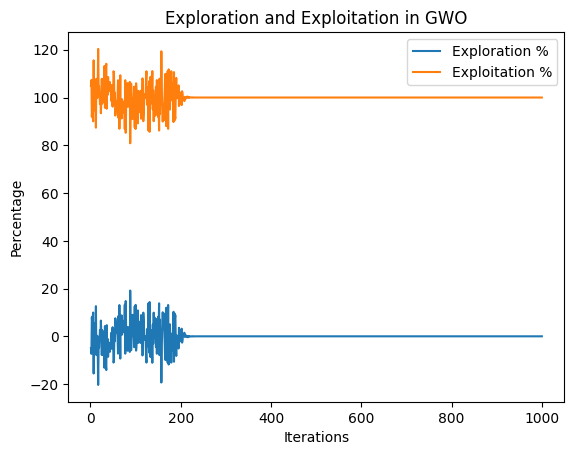

Best fitness: 6.131708417147196e-70


In [2]:


def GWO_with_profile(objf, lb, ub, dim, SearchAgents_no, Max_iter):
    Alpha_pos = np.zeros(dim)
    Alpha_score = float("inf")
    Beta_pos = np.zeros(dim)
    Beta_score = float("inf")
    Delta_pos = np.zeros(dim)
    Delta_score = float("inf")

    lb = np.array(lb).flatten()
    ub = np.array(ub).flatten()
    if lb.size == 1:
        lb = np.repeat(lb, dim)
    if ub.size == 1:
        ub = np.repeat(ub, dim)

    Positions = np.zeros((SearchAgents_no, dim))
    for i in range(dim):
        Positions[:, i] = np.random.uniform(0, 1, SearchAgents_no) * (ub[i] - lb[i]) + lb[i]

    Exploration = np.zeros(Max_iter)
    Exploitation = np.zeros(Max_iter)

    for l in range(Max_iter):
        for i in range(SearchAgents_no):
            for j in range(dim):
                Positions[i, j] = np.clip(Positions[i, j], lb[j], ub[j])
            fitness = objf(Positions[i, :])
            if fitness < Alpha_score:
                Alpha_score = fitness
                Alpha_pos = Positions[i, :].copy()
            if fitness > Alpha_score and fitness < Beta_score:
                Beta_score = fitness
                Beta_pos = Positions[i, :].copy()
            if fitness > Alpha_score and fitness > Beta_score and fitness < Delta_score:
                Delta_score = fitness
                Delta_pos = Positions[i, :].copy()

        dimensionwise_distances = Positions - np.median(Positions, axis=0)
        dimensionwise_diversity = np.mean(dimensionwise_distances, axis=0)
        population_diversity = np.mean(dimensionwise_diversity)
        max_diversity = np.max(np.abs(dimensionwise_diversity)) + 1e-12
        exploration_percentage = (population_diversity / max_diversity) * 100
        exploitation_percentage = (np.abs(population_diversity - max_diversity) / max_diversity) * 100
        Exploration[l] = exploration_percentage
        Exploitation[l] = exploitation_percentage

        for i in range(SearchAgents_no):
            for j in range(dim):
                r1 = np.random.random()
                r2 = np.random.random()
                a = 2 - l * (2 / Max_iter)
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = np.abs(C1 * Alpha_pos[j] - Positions[i, j])
                X1 = Alpha_pos[j] - A1 * D_alpha

                r1 = np.random.random()
                r2 = np.random.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = np.abs(C2 * Beta_pos[j] - Positions[i, j])
                X2 = Beta_pos[j] - A2 * D_beta

                r1 = np.random.random()
                r2 = np.random.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = np.abs(C3 * Delta_pos[j] - Positions[i, j])
                X3 = Delta_pos[j] - A3 * D_delta

                Positions[i, j] = (X1 + X2 + X3)/3

    iters = np.arange(1, Max_iter + 1)
    plt.figure()
    plt.plot(iters, Exploration, label='Exploration %')
    plt.plot(iters, Exploitation, label='Exploitation %')
    plt.xlabel('Iterations')
    plt.ylabel('Percentage')
    plt.title('Exploration and Exploitation in GWO')
    plt.legend()
    plt.show()

    return Alpha_pos, Alpha_score, Exploration, Exploitation

lb, ub, dim, fobj = Get_Functions_details('F1')
best_pos, best_fit, Exploration, Exploitation = GWO_with_profile(
    objf=fobj,
    lb=lb,
    ub=ub,
    dim=dim,
    SearchAgents_no=50,
    Max_iter=1000
)
print("Best fitness:", best_fit)

# Diversity Proposed - test to GWO

  Function      Mean_F       Std_F    Median_F      Best_F      Worst_F  \
0       F1  835.708077  281.326529  843.598264  402.216518  1408.272096   

   Mean_FE    Mean_D  Std_D_runs  Mean_Expl  Mean_Exploit  AUC_Expl_mean  \
0    750.0  0.080784     0.00291  19.971714     80.028286      17.966058   

   AUC_Exploit_mean  Conv_iter_mean  
0         78.033942       10.133333  


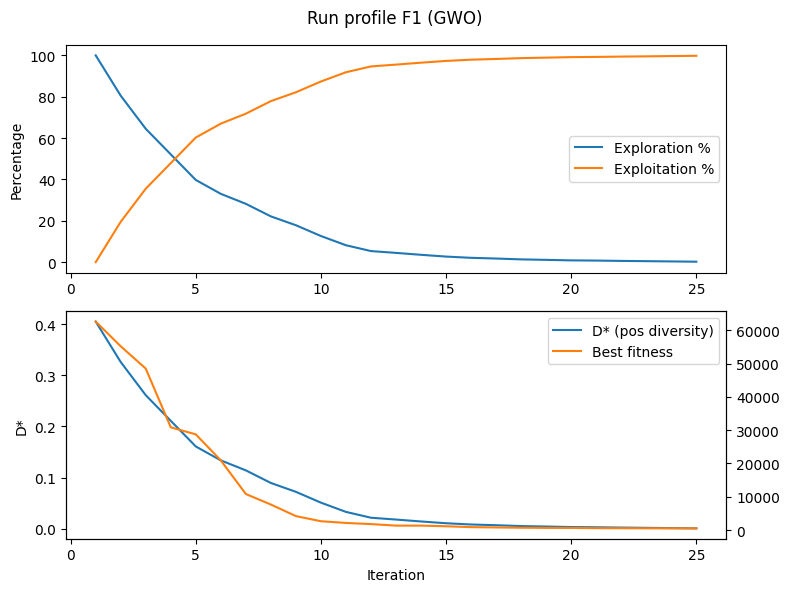

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Get_Functions_details import Get_Functions_details

def normalized_diversity(X, lb, ub, D0=None, eps=1e-12):
    X = np.asarray(X)
    N, d = X.shape
    lb = np.asarray(lb)
    ub = np.asarray(ub)
    if lb.size == 1:
        lb = np.full(d, lb.item())
    if ub.size == 1:
        ub = np.full(d, ub.item())
    Y = (X - lb) / (ub - lb)
    diff = Y[:, None, :] - Y[None, :, :]
    dist_matrix = np.linalg.norm(diff, axis=2) / np.sqrt(d)
    iu, ju = np.triu_indices(N, 1)
    D_star = dist_matrix[iu, ju].mean() if iu.size>0 else 0.0
    if D0 is None:
        return D_star
    return D_star / (D0 + eps)

def exploration_exploitation(X, lb, ub, D0):
    D_rel = normalized_diversity(X, lb, ub, D0=D0)
    return D_rel * 100.0, (1.0 - D_rel) * 100.0

def GWO_basic_record(objf, lb, ub, dim, SearchAgents_no, Max_iter):
    Alpha_pos = np.zeros(dim)
    Alpha_score = float("inf")
    Beta_pos = np.zeros(dim)
    Beta_score = float("inf")
    Delta_pos = np.zeros(dim)
    Delta_score = float("inf")
    lb = np.array(lb).flatten()
    ub = np.array(ub).flatten()
    if lb.size == 1:
        lb = np.repeat(lb, dim)
    if ub.size == 1:
        ub = np.repeat(ub, dim)
    Positions = np.zeros((SearchAgents_no, dim))
    for i in range(dim):
        Positions[:, i] = np.random.uniform(0, 1, SearchAgents_no) * (ub[i] - lb[i]) + lb[i]
    D0 = normalized_diversity(Positions, lb, ub)
    exploration_hist = []
    exploitation_hist = []
    diversity_hist = []
    best_f_history = []
    FE_count = 0
    for l in range(Max_iter):
        for i in range(SearchAgents_no):
            for j in range(dim):
                Positions[i, j] = np.clip(Positions[i, j], lb[j], ub[j])
            fitness = objf(Positions[i, :])
            FE_count += 1
            if fitness < Alpha_score:
                Alpha_score = fitness
                Alpha_pos = Positions[i, :].copy()
            if fitness > Alpha_score and fitness < Beta_score:
                Beta_score = fitness
                Beta_pos = Positions[i, :].copy()
            if fitness > Alpha_score and fitness > Beta_score and fitness < Delta_score:
                Delta_score = fitness
                Delta_pos = Positions[i, :].copy()
        exp_t, explot_t = exploration_exploitation(Positions, lb, ub, D0)
        exploration_hist.append(exp_t)
        exploitation_hist.append(explot_t)
        diversity_hist.append(normalized_diversity(Positions, lb, ub, D0=None))
        best_f_history.append(Alpha_score)
        for i in range(SearchAgents_no):
            for j in range(dim):
                r1 = np.random.random()
                r2 = np.random.random()
                a = 2 - l * (2 / Max_iter)
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = np.abs(C1 * Alpha_pos[j] - Positions[i, j])
                X1 = Alpha_pos[j] - A1 * D_alpha
                r1 = np.random.random()
                r2 = np.random.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = np.abs(C2 * Beta_pos[j] - Positions[i, j])
                X2 = Beta_pos[j] - A2 * D_beta
                r1 = np.random.random()
                r2 = np.random.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = np.abs(C3 * Delta_pos[j] - Positions[i, j])
                X3 = Delta_pos[j] - A3 * D_delta
                Positions[i, j] = (X1 + X2 + X3) / 3.0
    return {
        "best_pos": Alpha_pos,
        "best_f": Alpha_score,
        "exploration_hist": np.array(exploration_hist),
        "exploitation_hist": np.array(exploitation_hist),
        "diversity_hist": np.array(diversity_hist),
        "best_f_history": np.array(best_f_history),
        "FE": FE_count,
        "D0": D0
    }

def summarize_run(record, conv_threshold_rel=0.1):
    div = record["diversity_hist"]
    D0 = record["D0"]
    D_rel = div / (D0 + 1e-12)
    final_div = div[-1]
    mean_div = div.mean()
    std_div = div.std()
    exploration = record["exploration_hist"]
    exploitation = record["exploitation_hist"]
    auc_expl = np.trapz(exploration, dx=1) / len(exploration)
    auc_exploit = np.trapz(exploitation, dx=1) / len(exploitation)

    conv_iter = next((i for i,v in enumerate(D_rel) if v < conv_threshold_rel), len(D_rel)-1)
    return {
        "Final_D": float(final_div),
        "Mean_D": float(mean_div),
        "Std_D": float(std_div),
        "Mean_Expl": float(exploration.mean()),
        "Mean_Exploit": float(exploitation.mean()),
        "AUC_Expl": float(auc_expl),
        "AUC_Exploit": float(auc_exploit),
        "Conv_iter": int(conv_iter),
        "FE": int(record["FE"])
    }

def run_benchmark(func_names, runs=30, SearchAgents_no=30, Max_iter=25, conv_threshold_rel=0.1):
    rows = []
    detail_profiles = {}
    for fname in func_names:
        lb, ub, dim, fobj = Get_Functions_details(fname)
        fitness_list = []
        run_div_stats = []
        run_fe = []
        profiles = []
        for r in range(runs):
            rec = GWO_basic_record(fobj, lb, ub, dim, SearchAgents_no, Max_iter)
            fitness_list.append(rec["best_f"])
            run_fe.append(rec["FE"])
            summ = summarize_run(rec, conv_threshold_rel=conv_threshold_rel)
            run_div_stats.append(summ)
            profiles.append(rec)
        fitness_arr = np.array(fitness_list)
        fe_arr = np.array(run_fe)
        mean_D = np.mean([s["Mean_D"] for s in run_div_stats])
        std_D = np.std([s["Mean_D"] for s in run_div_stats])
        mean_expl = np.mean([s["Mean_Expl"] for s in run_div_stats])
        mean_exploit = np.mean([s["Mean_Exploit"] for s in run_div_stats])
        auc_expl_mean = np.mean([s["AUC_Expl"] for s in run_div_stats])
        auc_exploit_mean = np.mean([s["AUC_Exploit"] for s in run_div_stats])
        conv_mean = np.mean([s["Conv_iter"] for s in run_div_stats])
        rows.append({
            "Function": fname,
            "Mean_F": float(fitness_arr.mean()),
            "Std_F": float(fitness_arr.std()),
            "Median_F": float(np.median(fitness_arr)),
            "Best_F": float(fitness_arr.min()),
            "Worst_F": float(fitness_arr.max()),
            "Mean_FE": float(fe_arr.mean()),
            "Mean_D": float(mean_D),
            "Std_D_runs": float(std_D),
            "Mean_Expl": float(mean_expl),
            "Mean_Exploit": float(mean_exploit),
            "AUC_Expl_mean": float(auc_expl_mean),
            "AUC_Exploit_mean": float(auc_exploit_mean),
            "Conv_iter_mean": float(conv_mean)
        })
        detail_profiles[fname] = profiles
    df = pd.DataFrame(rows)
    return df, detail_profiles

def plot_profile_one_run(profile, title=None):
    expl = profile["exploration_hist"]
    exploit = profile["exploitation_hist"]
    div = profile["diversity_hist"]
    bestf = profile["best_f_history"]
    it = np.arange(1, len(expl)+1)
    fig, axs = plt.subplots(2,1, figsize=(8,6))
    axs[0].plot(it, expl, label="Exploration %")
    axs[0].plot(it, exploit, label="Exploitation %")
    axs[0].set_ylabel("Percentage")
    axs[0].legend()
    axs[1].plot(it, div, label="D* (pos diversity)")
    axs1b = axs[1].twinx()
    axs1b.plot(it, bestf, color="tab:orange", label="Best fitness")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("D*")
    lines, labels = axs[1].get_legend_handles_labels()
    lines2, labels2 = axs1b.get_legend_handles_labels()
    axs[1].legend(lines+lines2, labels+labels2, loc="upper right")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

func_names = [f"F{i}" for i in range(1,2)]
df_summary, details = run_benchmark(func_names, runs=30, SearchAgents_no=30, Max_iter=25, conv_threshold_rel=0.1)
print(df_summary)
df_summary.to_csv("gwo_benchmark_summary.csv", index=False)
example_profile = details["F1"][0]
plot_profile_one_run(example_profile, title="Run profile F1 (GWO)")

In [ ]:
[3, 4, 5]

[3,4, 6]

****premature convergence